In [1]:
pip install polars matplotlib typing_extensions==4.11.0 great_tables

Note: you may need to restart the kernel to use updated packages.


In [61]:
import polars as pl
import matplotlib.pyplot as plt
from great_tables import GT, style, loc

In [36]:


schema = pl.Schema({"Timers":pl.UInt64(), "TxTime":pl.UInt64(), "RxTime":pl.UInt64()})
formats=[720, 1080, 2160]

raw_native={}
raw_libfabric={}
for format in formats:
    raw_native[format]=pl.read_csv(f"../data/cuda2cuda-intergpu/NativeCuda+Cuda2Cuda{format}.csv", schema=schema);
    raw_libfabric[format]=pl.read_csv(f"../data/cuda2cuda-intergpu/MXLFabrics+Cuda2Cuda+SHM+OneWay+Spin{format}.csv", schema=schema);

y_native ={}
y_libfabric={}
for format in formats:
    y_native[format] = raw_native[format].select(pl.col("Timers"))
    y_libfabric[format] = raw_libfabric[format].select(pl.col("RxTime")) - raw_libfabric[format].select(pl.col("TxTime"))




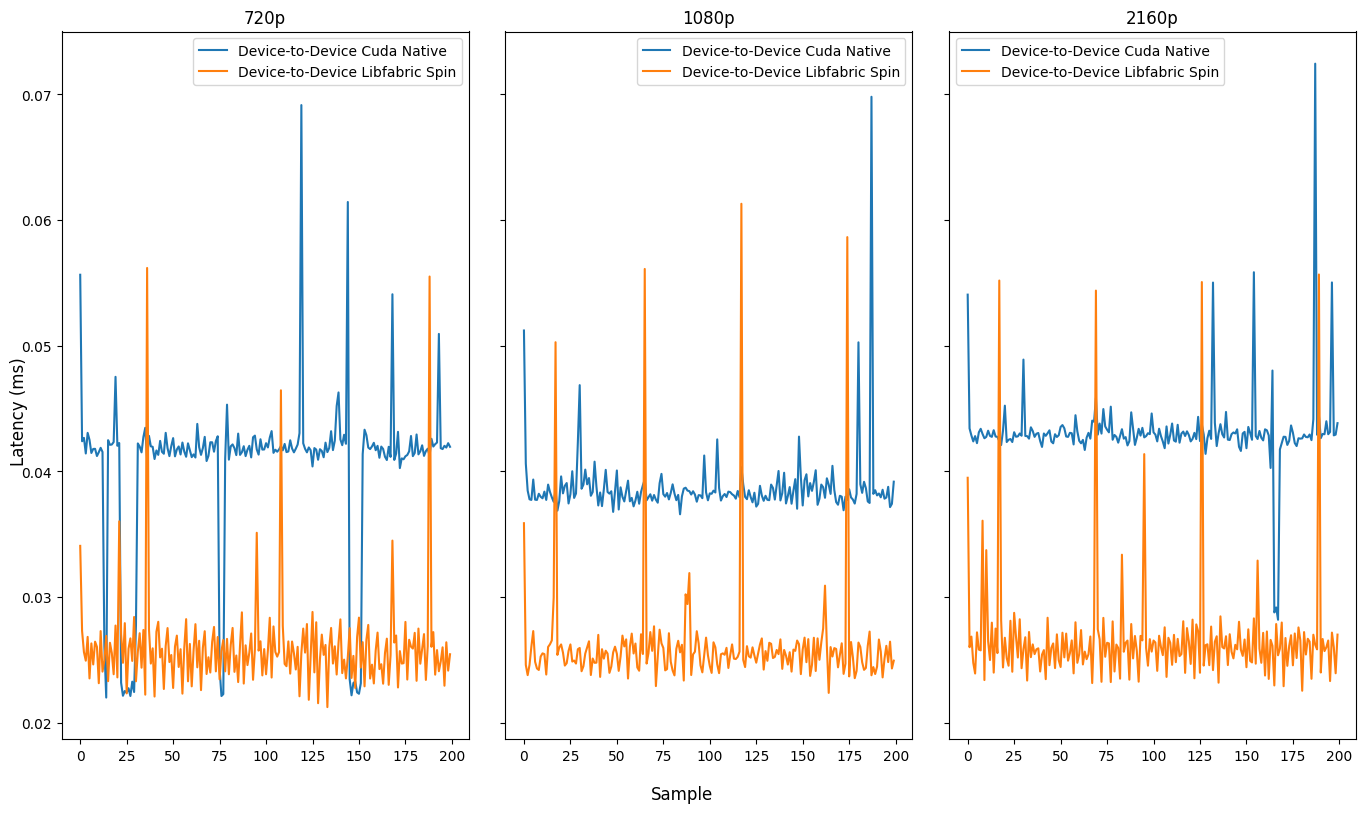

In [37]:
plt.rcParams['figure.figsize'] = [14,8]
fig, axs = plt.subplots(nrows=1,ncols=len(formats), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(formats):
    axs[i].set_title(f"{format}p")
    # axs[i].set_ylim(0,2)
    axs[i].plot(y_native[format][:200]/1e6, label=f"Device-to-Device Cuda Native")
    axs[i].plot(y_libfabric[format][:200]/1e6, label=f"Device-to-Device Libfabric Spin")
    axs[i].legend()

In [66]:
# Device-to-Device intra-host inter-gpu comparison table

# Library Format, Average Latency, Max latency, Latency StdDev
x = y_native[720].mean()

d2d_intergpu_data = {"Library":[], "Format":[], "Mean":[], "Max":[], "STD":[]}
for format in formats:
    d2d_intergpu_data["Library"].append("Native")
    d2d_intergpu_data["Format"].append(format)
    d2d_intergpu_data["Mean"].append(y_native[format].mean()[0].cast(pl.Decimal(None,scale=2)).item())
    d2d_intergpu_data["Max"].append(y_native[format].max()[0].cast(pl.Decimal(None,scale=2)).item())
    d2d_intergpu_data["STD"].append(y_native[format].std()[0].cast(pl.Decimal(None,scale=2)).item())
    
for format in formats:
    d2d_intergpu_data["Library"].append("libfabric")
    d2d_intergpu_data["Format"].append(format)
    d2d_intergpu_data["Mean"].append(y_libfabric[format].mean()[0].cast(pl.Decimal(None,scale=2)).item())
    d2d_intergpu_data["Max"].append(y_libfabric[format].max()[0].cast(pl.Decimal(None,scale=2)).item())
    d2d_intergpu_data["STD"].append(y_libfabric[format].std()[0].cast(pl.Decimal(None,scale=2)).item())
    
d2d_intergpu_data = pl.DataFrame(d2d_intergpu_data)


d2d_intergpu_table = GT(d2d_intergpu_data)
(
    d2d_intergpu_table
    .tab_header(
        title="Device-to-Device transfer latency comparison.",
        subtitle="Intra-host Inter-gpu",
    )
    .tab_spanner(
        label="Configuration",
        columns=["Library","Format"]
    )
    .tab_spanner(
        label="Latency Measurements",
        columns=["Mean", "Max", "STD"]
    )
    .tab_style(
        style.fill("lightyellow"),
        loc.body(
            columns = pl.selectors.all(),
            rows = pl.col("Max") == pl.col("Max").max()
        )
    )
)



GT(_tbl_data=shape: (6, 5)
┌───────────┬────────┬──────────────┬──────────────┬──────────────┐
│ Library   ┆ Format ┆ Mean         ┆ Max          ┆ STD          │
│ ---       ┆ ---    ┆ ---          ┆ ---          ┆ ---          │
│ str       ┆ i64    ┆ decimal[*,2] ┆ decimal[*,2] ┆ decimal[*,2] │
╞═══════════╪════════╪══════════════╪══════════════╪══════════════╡
│ Native    ┆ 720    ┆ 40386.91     ┆ 69133.00     ┆ 6606.11      │
│ Native    ┆ 1080   ┆ 38690.47     ┆ 69794.00     ┆ 2762.20      │
│ Native    ┆ 2160   ┆ 43151.30     ┆ 72428.00     ┆ 3326.82      │
│ libfabric ┆ 720    ┆ 25613.55     ┆ 67440.00     ┆ 3143.61      │
│ libfabric ┆ 1080   ┆ 25679.52     ┆ 63445.00     ┆ 3443.05      │
│ libfabric ┆ 2160   ┆ 26142.22     ┆ 64587.00     ┆ 3478.12      │
└───────────┴────────┴──────────────┴──────────────┴──────────────┘, _body=<great_tables._gt_data.Body object at 0x7cf4b1917ad0>, _boxhead=Boxhead([ColInfo(var='Library', type=<ColInfoTypeEnum.default: 1>, column_label='Library', column_align='left', column_width=None), ColInfo(var='Format', type=<ColInfoTypeEnum.default: 1>, column_label='Format', column_align='right', column_width=None), ColInfo(var='Mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='center', column_width=None), ColInfo(var='Max', type=<ColInfoTypeEnum.default: 1>, column_label='Max', column_align='center', column_width=None), ColInfo(var='STD', type=<ColInfoTypeEnum.default: 1>, column_label='STD', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7cf4b1660b50>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['Library', 'Format'], built=None), SpannerInfo(spanner_id='Latency Measurements', spanner_level=0, spanner_label='Latency Measurements', spanner_units=None, spanner_pattern=None, vars=['Mean', 'Max', 'STD'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison.', subtitle='Intra-host Inter-gpu', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7CF4B17D9890>, mask=None), grpname=None, colname='Library', rownum=2, colnum=None, styles=[CellStyleFill(color='lightyellow')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7CF4B17D9890>, mask=None), grpname=None, colname='Format', rownum=2, colnum=None, styles=[CellStyleFill(color='lightyellow')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7CF4B17D9890>, mask=None), grpname=None, colname='Mean', rownum=2, colnum=None, styles=[CellStyleFill(color='lightyellow')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7CF4B17D9890>, mask=None), grpname=None, colname='Max', rownum=2, colnum=None, styles=[CellStyleFill(color='lightyellow')]), StyleInfo(locname=LocBody(columns=cs.all(), rows=<Expr ['[(col("Max")) == (col("Max").m…'] at 0x7CF4B17D9890>, mask=None), grpname=None, colname='STD', rownum=2, colnum=None, styles=[CellStyleFill(color='lightyellow')])], _locale=<great_tables._gt_data.Locale object at 0x7cf4b16f5a10>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=

In [64]:
schema = pl.Schema({"Timers":pl.UInt64(), "TxTime":pl.UInt64(), "RxTime":pl.UInt64()})
formats=[720, 1080, 2160]

raw_native={}
raw_libfabric={}
for format in formats:
    raw_native[format]=pl.read_csv(f"../gpu2gpu/{format}/NativeCuda+Cuda2Cuda.csv", schema=schema);
    raw_libfabric[format]=pl.read_csv(f"../gpu2gpu/{format}/MXLFabrics+Cuda2Cuda+SHM+OneWay+Spin.csv", schema=schema)
    

y_native={}
y_libfabric={}
for format in formats:
    y_native[format] = raw_native[format].select(pl.col("Timers"))
    y_libfabric[format] = raw_libfabric[format].select(pl.col("RxTime")) - raw_libfabric[format].select(pl.col("TxTime"))

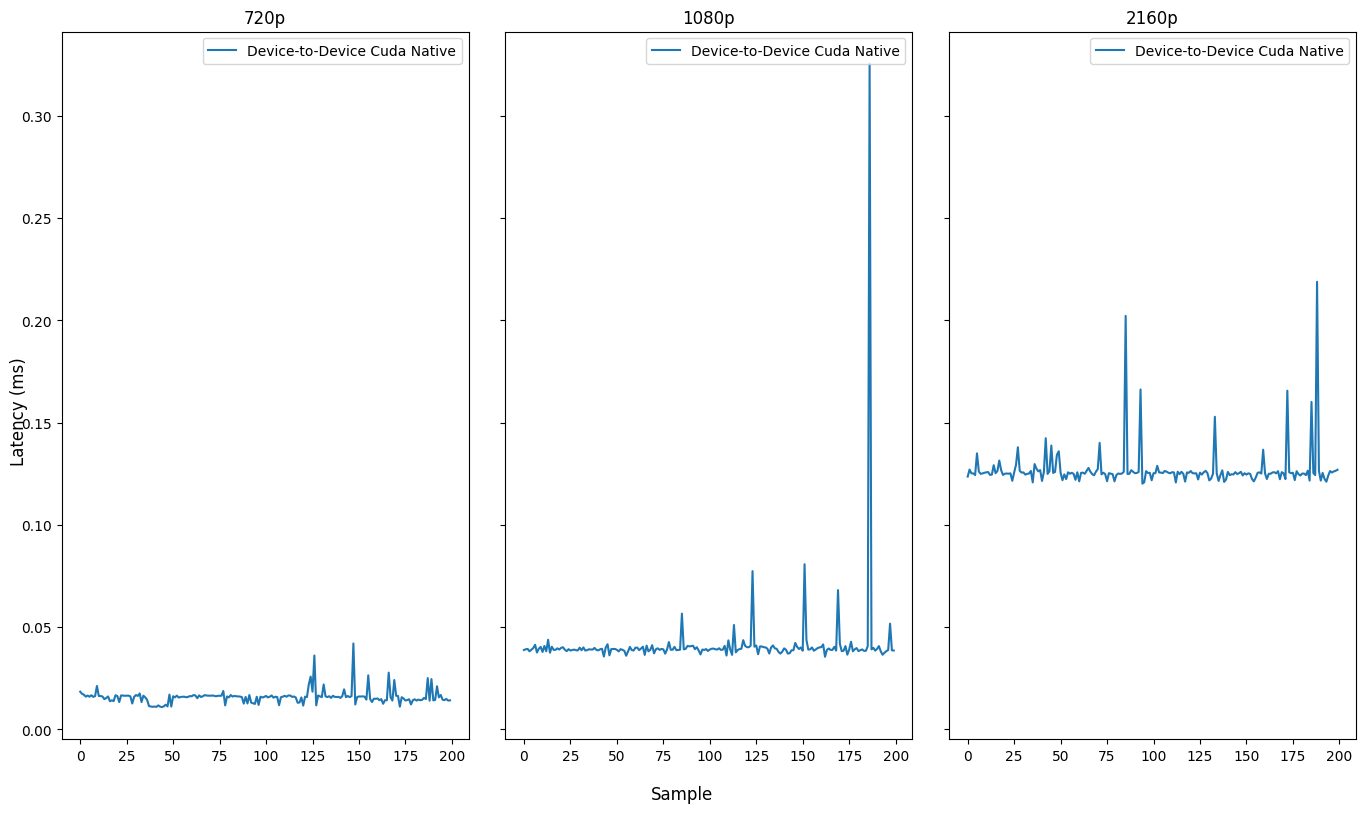

In [66]:
plt.rcParams['figure.figsize'] = [14,8]
fig, axs = plt.subplots(nrows=1,ncols=len(formats), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(formats):
    axs[i].set_title(f"{format}p")
    # axs[i].set_ylim(0,2)
    axs[i].plot(y_native[format][:200]/1e6, label=f"Device-to-Device Cuda Native")
    #axs[i].plot(y_libfabric[format][:200]/1e6, label=f"Device-to-Device Cuda Native")
    axs[i].legend()

In [51]:
y_native[720].max()

Timers
u64
41942


In [52]:
y_native[720].mean()

Timers
f64
15796.095


In [ ]:
1